In [49]:
import numpy as np
import networkx as nx

TODO: Explore symbolic ml/symbolic regression with Mathematica

### Data Generation

In [50]:
def isospectral_reduction(A, S_indices, lam):
    """
    Compute A[S,S] - A[S,Sbar] @ inv(A[Sbar,Sbar] - lam I) @ A[Sbar,S]
    A: (n,n) numpy array (symmetric adjacency)
    S_indices: list/array of kept vertex indices (0-based)
    lam: scalar (float)
    Returns: reduced matrix (len(S_indices) x len(S_indices))
    """
    n = A.shape[0]
    S = np.array(S_indices, dtype=int)
    Sbar = np.setdiff1d(np.arange(n), S)
    A_SS = A[np.ix_(S, S)]
    if Sbar.size == 0:
        return A_SS.copy()
    A_S_Sbar = A[np.ix_(S, Sbar)]
    A_Sbar_S = A[np.ix_(Sbar, S)]
    A_Sbar_Sbar = A[np.ix_(Sbar, Sbar)]
    M = A_Sbar_Sbar - lam * np.eye(len(Sbar))
    try:
        Minv = np.linalg.inv(M)
    except np.linalg.LinAlgError:
        Minv = np.linalg.pinv(M + 1e-8 * np.eye(M.shape[0]))
    return A_SS - A_S_Sbar @ Minv @ A_Sbar_S

def evaluate_reduction_multilambda(A, S_indices, lambdas):
    """Evaluate the reduced matrix at multiple lambda points and return a stacked array of shape (k, m, m)"""
    return np.stack([isospectral_reduction(A, S_indices, lam) for lam in lambdas], axis=0)

In [51]:
def generate_dataset_er(n_graphs=200, n=12, p=0.25, m_keep=5, lambdas=None, seed=123):
    rng = np.random.RandomState(seed)
    if lambdas is None:
        lambdas = np.linspace(-2.0, 2.0, 9)
    data = []
    for i in range(n_graphs):
        G = nx.erdos_renyi_graph(n, p, seed=rng.randint(0, 1000000))
        tries = 0
        while (not nx.is_connected(G)) and tries < 5:
            G = nx.erdos_renyi_graph(n, p, seed=rng.randint(0, 1000000))
            tries += 1
        A = nx.to_numpy_array(G, dtype=float)
        S = rng.choice(n, size=m_keep, replace=False)
        R_multi = evaluate_reduction_multilambda(A, S, lambdas)
        data.append({'A': A, 'S': np.sort(S), 'R': R_multi})
    return data, np.array(lambdas)


In [52]:
data, lambdas = generate_dataset_er(n_graphs=100, n=15, p=0.25, m_keep=5)
print("Dataset size:", len(data), "lambdas:", lambdas)
print("Original graph n:", data[0]['A'].shape[0], "Reduced m:", data[0]['R'].shape[1])

Dataset size: 100 lambdas: [-2.  -1.5 -1.  -0.5  0.   0.5  1.   1.5  2. ]
Original graph n: 15 Reduced m: 5


In [53]:
def R_multilambda_to_feature(R_multi):
    """Flatten the multi-lambda reduced matrix into a feature vector"""
    k, m, _ = R_multi.shape
    idx = np.triu_indices(m, k=0)
    feats = []
    for i in range(k):
        feats.append(R_multi[i][idx])
    return np.concatenate(feats)

def A_to_upper_triangle_vector(A):
    """Return upper triangle (k=1) of adjacency matrix as a vector"""
    iu = np.triu_indices(A.shape[0], k=1)
    return A[iu]

In [54]:
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    print("PyTorch available")
except Exception as e:
    print("PyTorch not available; install it to train the baseline.")
    torch = None

def try_train_baseline(data, lambdas, epochs=10, batch_size=32, lr=1e-3, device='cpu'):
    if torch is None:
        return None
    k = len(lambdas)
    m = data[0]['R'].shape[1]
    n = data[0]['A'].shape[0]
    X = np.array([R_multilambda_to_feature(d['R']) for d in data])
    Y = np.array([A_to_upper_triangle_vector(d['A']) for d in data])
    X_t = torch.tensor(X, dtype=torch.float32, device=device)
    Y_t = torch.tensor(Y, dtype=torch.float32, device=device)

    input_dim = X_t.shape[1]
    output_dim = Y_t.shape[1]

    class MLP(nn.Module):
        def __init__(self, in_dim, out_dim, hidden=256):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(in_dim, hidden),
                nn.ReLU(),
                nn.Linear(hidden, hidden),
                nn.ReLU(),
                nn.Linear(hidden, out_dim)
            )
        def forward(self, x):
            return self.net(x)

    model = MLP(input_dim, output_dim).to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    N = X.shape[0]
    idxs = np.arange(N)
    for epoch in range(1, epochs+1):
        np.random.shuffle(idxs)
        model.train()
        epoch_loss = 0.0
        for start in range(0, N, batch_size):
            batch_idx = idxs[start:start+batch_size]
            xb = X_t[batch_idx]
            yb = Y_t[batch_idx]
            opt.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            opt.step()
            epoch_loss += float(loss.item()) * xb.shape[0]
        epoch_loss /= N
        print(f"Epoch {epoch}/{epochs} loss={epoch_loss:.4f}")
    return {'model': model.to('cpu'), 'lambdas': lambdas, 'm': m, 'n': n}

PyTorch available


In [55]:
def sample_and_show(model_pack, data, num_examples=3):
    if torch is None:
        print("PyTorch not available")
        return
    model = model_pack['model']
    lambdas = model_pack['lambdas']
    m = model_pack['m']
    n = model_pack['n']
    N = len(data)
    for i in range(num_examples):
        idx = np.random.randint(0, N)
        d = data[idx]
        X = torch.tensor(R_multilambda_to_feature(d['R']), dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            logits = model(X).squeeze(0).numpy()
            probs = 1.0 / (1.0 + np.exp(-logits))
        A_hat = np.zeros((n, n))
        iu = np.triu_indices(n, k=1)
        A_hat[iu] = (probs > 0.5).astype(float)
        A_hat = A_hat + A_hat.T
        R_hat_multi = evaluate_reduction_multilambda(A_hat, d['S'], lambdas)
        err = np.sqrt(np.sum((R_hat_multi - d['R'])**2))
        print(f"Example {i}: reduction error (Frobenius over lambdas) = {err:.4g}")
        print("True edges:", int(np.sum(d['A'])/2), "Pred edges:", int(np.sum(A_hat)/2))
        print("First 6x6 block of predicted adjacency:")
        print(A_hat[:6,:6])
        print("-"*40)

In [56]:
data, lambdas = generate_dataset_er(n_graphs=800, n=10, p=0.25, m_keep=1)
model_pack = try_train_baseline(data, lambdas, epochs=12, batch_size=64, lr=1e-3)
if model_pack is not None:
    sample_and_show(model_pack, data, num_examples=5)

Epoch 1/12 loss=76401780131197036542296064.0000
Epoch 2/12 loss=80911333168514509521813504.0000
Epoch 3/12 loss=91873929169177151772033024.0000
Epoch 4/12 loss=88082831065603559485603840.0000
Epoch 5/12 loss=89587371124087368896741376.0000
Epoch 6/12 loss=89707767857568177230708736.0000
Epoch 7/12 loss=89707767857568434928746496.0000
Epoch 8/12 loss=89436515126792374332686336.0000
Epoch 9/12 loss=89704131635376468621524992.0000
Epoch 10/12 loss=87452725705793952112705536.0000
Epoch 11/12 loss=87452743414668245006811136.0000
Epoch 12/12 loss=87611615629068195292250112.0000
Example 0: reduction error (Frobenius over lambdas) = 1.364e+08
True edges: 14 Pred edges: 15
First 6x6 block of predicted adjacency:
[[0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 1. 0. 0.]
 [0. 1. 0. 0. 0. 1.]
 [1. 1. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0.]]
----------------------------------------
Example 1: reduction error (Frobenius over lambdas) = 1.288e+08
True edges: 17 Pred edges: 15
First 6x6 block of predic

/tmp/ipykernel_10726/3018672698.py:16: RuntimeWarning: overflow encountered in exp
  probs = 1.0 / (1.0 + np.exp(-logits))


In [57]:
import matplotlib.pyplot as plt

def visualize_graphs_side_by_side(true_A, pred_A, node_labels=None, title_true="True Graph", title_pred="Predicted Graph"):
    """
    Draw two graphs side by side from adjacency matrices true_A and pred_A
    """
    n = true_A.shape[0]
    G_true = nx.from_numpy_array(true_A)
    G_pred = nx.from_numpy_array(pred_A)
    
    # Layout (consistent for both)
    pos = nx.spring_layout(G_true, seed=42)
    
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    nx.draw_networkx(G_true, pos=pos, with_labels=True, node_color='lightblue', edge_color='gray')
    plt.title(title_true)
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    nx.draw_networkx(G_pred, pos=pos, with_labels=True, node_color='lightgreen', edge_color='gray')
    plt.title(title_pred)
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

def sample_and_visualize(model_pack, data, num_examples=1, threshold=0.5):
    """
    Pick random examples, predict adjacency, compute predicted reduction error,
    and visualize the graphs.
    """
    if torch is None:
        print("PyTorch not available")
        return
    model = model_pack['model']
    lambdas = model_pack['lambdas']
    m = model_pack['m']
    n = model_pack['n']
    N = len(data)
    for i in range(num_examples):
        idx = np.random.randint(0, N)
        d = data[idx]
        X = torch.tensor(R_multilambda_to_feature(d['R']), dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            logits = model(X).squeeze(0).numpy()
            probs = 1.0 / (1.0 + np.exp(-logits))
        A_hat = np.zeros((n, n))
        iu = np.triu_indices(n, k=1)
        A_hat[iu] = (probs > threshold).astype(float)
        A_hat = A_hat + A_hat.T
        R_hat_multi = evaluate_reduction_multilambda(A_hat, d['S'], lambdas)
        err = np.sqrt(np.sum((R_hat_multi - d['R'])**2))
        print(f"Example {i}: reduction error (Frobenius over lambdas) = {err:.4g}")
        print("True edges:", int(np.sum(d['A'])/2), "Pred edges:", int(np.sum(A_hat)/2))
        
        visualize_graphs_side_by_side(d['A'], A_hat, title_true="True Graph", title_pred=f"Predicted Graph (err={err:.2f})")

/tmp/ipykernel_10726/3139571764.py:47: RuntimeWarning: overflow encountered in exp
  probs = 1.0 / (1.0 + np.exp(-logits))


Example 0: reduction error (Frobenius over lambdas) = 7.071e+07
True edges: 14 Pred edges: 15


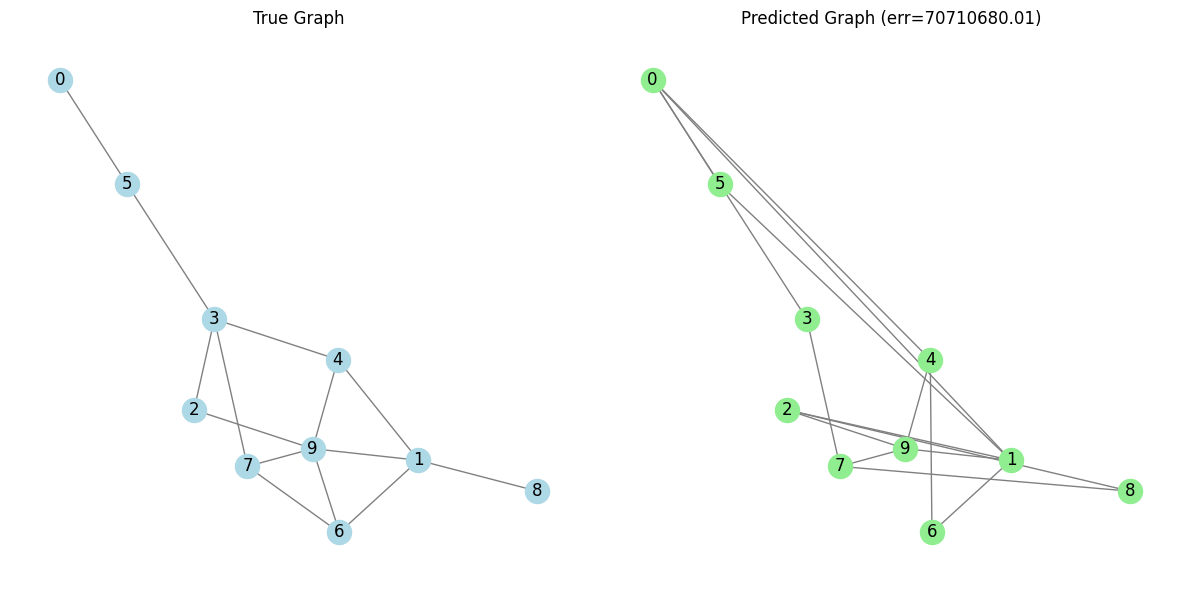

Example 1: reduction error (Frobenius over lambdas) = 3.333e+07
True edges: 17 Pred edges: 18


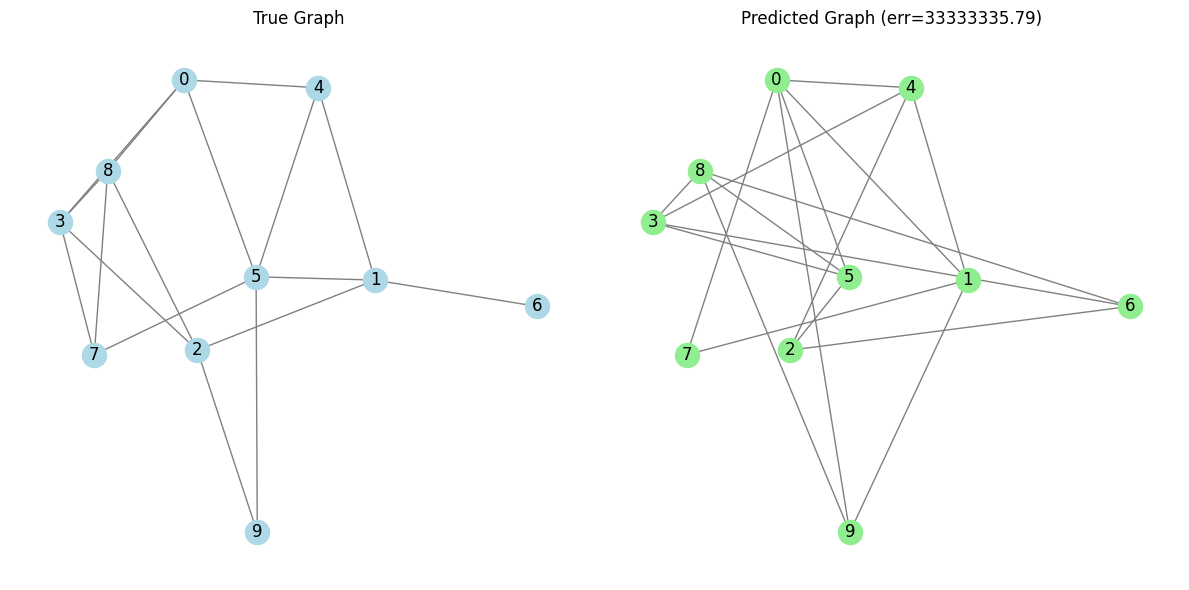

Example 2: reduction error (Frobenius over lambdas) = 1.057e+08
True edges: 13 Pred edges: 13


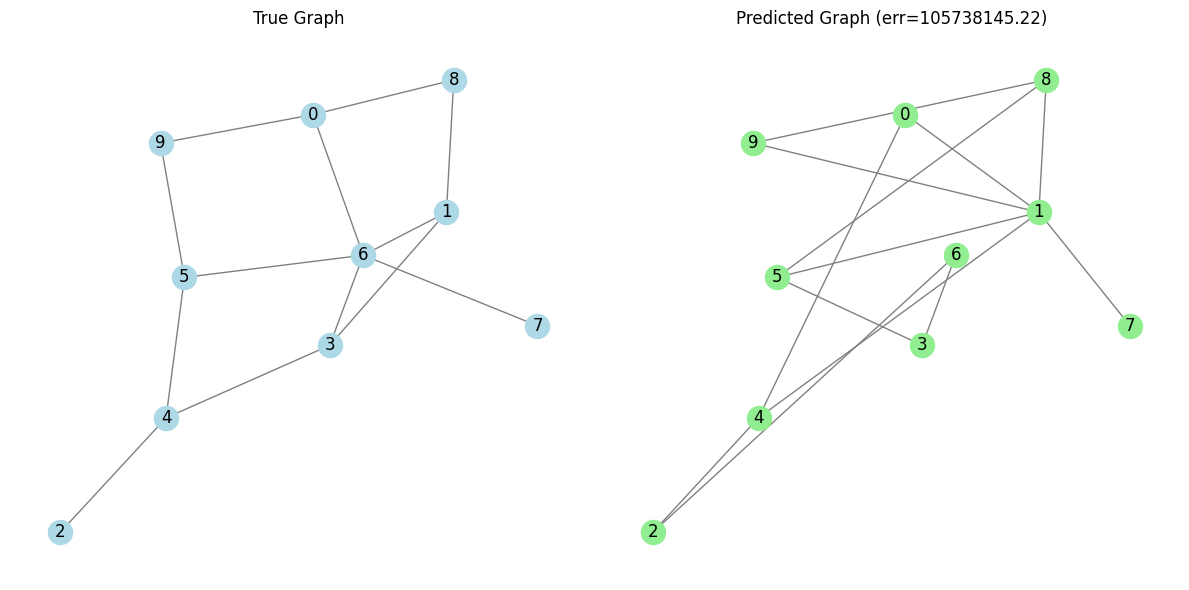

In [58]:
if model_pack is not None:
    sample_and_visualize(model_pack, data, num_examples=3)

In [59]:
# Cell 9: Visualize isospectral reductions of true vs. predicted graphs
def plot_isospectral_reductions(true_A, pred_A, S_indices, lambdas, mode='lines'):
    """
    Compare isospectral reductions of true and predicted graphs across λ values.
    mode: 'lines' (plot entries vs λ) or 'heatmap' (show |R| as color)
    """
    # Compute reductions
    R_true = evaluate_reduction_multilambda(true_A, S_indices, lambdas)
    R_pred = evaluate_reduction_multilambda(pred_A, S_indices, lambdas)
    k, m, _ = R_true.shape

    if mode == 'lines':
        plt.figure(figsize=(10, 6))
        for i in range(m):
            for j in range(i, m):
                plt.plot(lambdas, R_true[:, i, j], 'k-', alpha=0.6, label='True' if (i,j)==(0,0) else "")
                plt.plot(lambdas, R_pred[:, i, j], 'r--', alpha=0.6, label='Pred' if (i,j)==(0,0) else "")
        plt.xlabel("λ")
        plt.ylabel("Matrix entry value")
        plt.title("Isospectral Reductions (True vs Predicted)")
        plt.legend()
        plt.grid(True)
        plt.show()

    elif mode == 'heatmap':
        fig, axes = plt.subplots(2, k, figsize=(2*k, 5), sharex=True, sharey=True)
        for i, lam in enumerate(lambdas):
            im1 = axes[0, i].imshow(np.real(R_true[i]), cmap='viridis', vmin=-1, vmax=1)
            axes[0, i].set_title(f"True λ={lam:.2f}")
            axes[0, i].axis('off')
            im2 = axes[1, i].imshow(np.real(R_pred[i]), cmap='viridis', vmin=-1, vmax=1)
            axes[1, i].set_title(f"Pred λ={lam:.2f}")
            axes[1, i].axis('off')
        plt.suptitle("Isospectral Reduction Heatmaps (Top=True, Bottom=Predicted)")
        plt.colorbar(im1, ax=axes, orientation='vertical', fraction=0.02)
        plt.tight_layout()
        plt.show()

    else:
        raise ValueError("mode must be 'lines' or 'heatmap'")

In [60]:
# Cell 10: Run reduction comparison on one sample
def sample_and_compare_reductions(model_pack, data, sample_idx=None, mode='lines', threshold=0.5):
    if torch is None:
        print("PyTorch not available")
        return
    model = model_pack['model']
    lambdas = model_pack['lambdas']
    m = model_pack['m']
    n = model_pack['n']
    N = len(data)
    if sample_idx is None:
        sample_idx = np.random.randint(0, N)
    d = data[sample_idx]

    # Predict adjacency
    X = torch.tensor(R_multilambda_to_feature(d['R']), dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        logits = model(X).squeeze(0).numpy()
        probs = 1.0 / (1.0 + np.exp(-logits))
    A_hat = np.zeros((n, n))
    iu = np.triu_indices(n, k=1)
    A_hat[iu] = (probs > threshold).astype(float)
    A_hat = A_hat + A_hat.T

    # Compute error
    R_hat_multi = evaluate_reduction_multilambda(A_hat, d['S'], lambdas)
    err = np.sqrt(np.sum((R_hat_multi - d['R'])**2))
    print(f"Sample {sample_idx}: reduction Frobenius error = {err:.4g}")

    # Plot reductions
    plot_isospectral_reductions(d['A'], A_hat, d['S'], lambdas, mode=mode)

Sample 736: reduction Frobenius error = 1.818e+08


/tmp/ipykernel_10726/1446318837.py:19: RuntimeWarning: overflow encountered in exp
  probs = 1.0 / (1.0 + np.exp(-logits))


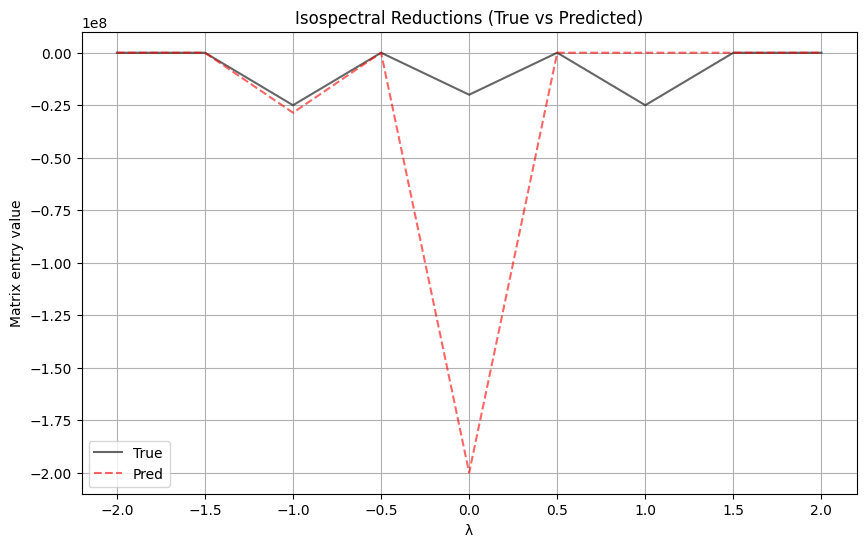

In [68]:
# Cell 11: Visualize isospectral reduction comparison for one example
if model_pack is not None:
    sample_and_compare_reductions(model_pack, data, mode='lines')